## Goal

Visualize Keras version adoption by plotting download counts per version.

Success criteria:
- load the CSV export from BigQuery
- filter versions with fewer than 500,000 downloads
- sort by download count
- render a labeled bar chart

## Requisites

- Python 3.9+
- `pandas`
- `matplotlib`
- Input file: `bquxjob_7e772f9e_1985d03a1ba.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load CSV file
file_path = 'bquxjob_7e772f9e_1985d03a1ba.csv'
df = pd.read_csv(file_path)
df.head()

,version,download_count
0,3.9.0,3650146
1,2.15.0,1057403
2,2.13.1,907281
3,2.11.0,815667
4,2.12.0,813414


In [3]:
# Filter out versions below a threshold
threshold = 500_000
filtered_df = df[df['download_count'] >= threshold].copy()

# Sort by download count descending
filtered_df = filtered_df.sort_values(by='download_count', ascending=False)
filtered_df

,version,download_count
0,3.9.0,3650146
1,2.15.0,1057403
2,2.13.1,907281
3,2.11.0,815667
4,2.12.0,813414
5,2.10.0,611584
6,2.14.0,548016


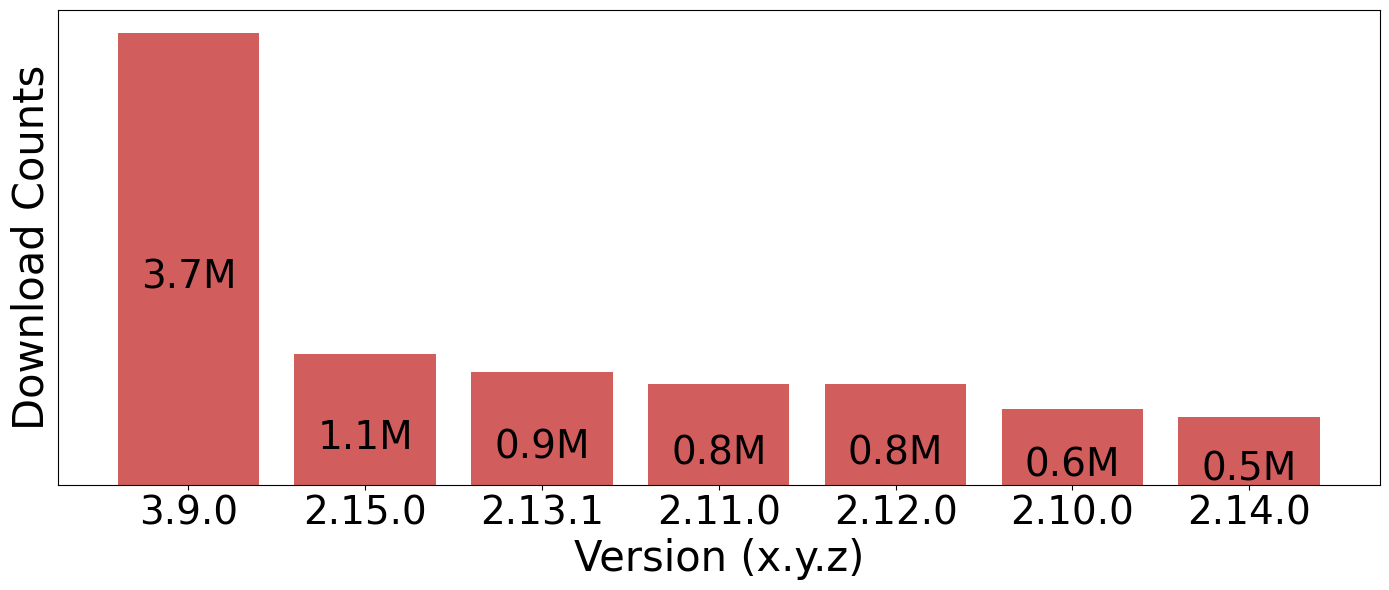

In [4]:
# Plot
plt.figure(figsize=(14, 6))
bars = plt.bar(filtered_df['version'], filtered_df['download_count'], color='#D25D5D')

# Add formatted text annotations above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height // 2,
        f'{height/1_000_000:.1f}M',
        ha='center',
        va='top',
        fontsize=28
    )

plt.xlabel('Version (x.y.z)', fontsize=30)
plt.ylabel('Download Counts', fontsize=30)
plt.xticks(rotation=0, fontsize=28)
plt.yticks([], fontsize=28)
plt.tight_layout()
plt.show()